### CARREGAMENTO DO DATASET

In [28]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

DATASET_HANDLE = "yashdevladdha/uber-ride-analytics-dashboard"
CSV_FILE = "ncr_ride_bookings.csv"


df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,DATASET_HANDLE,
        CSV_FILE,pandas_kwargs={"na_values": ["null"]})


df["Booking Value"] = pd.to_numeric(df["Booking Value"], errors="coerce")
df["Booking ID"] = df["Booking ID"].str.replace('"','',regex=False)
df["Customer ID"] = df["Customer ID"].str.replace('"','',regex=False)
df["Date"] = pd.to_datetime(df["Date"])
df["Time"]= pd.to_datetime(df["Time"], format="%H:%M:%S")
df_modelo = df[df["Booking Status"] == "Completed"].copy()

df_modelo["hora"] = df_modelo["Time"].dt.hour #0 a 23
df_modelo["dia_semana"] = df_modelo["Date"].dt.dayofweek #
df_modelo["mes"] = df_modelo["Date"].dt.month #1 a 12
df_modelo["final_semana"] = df_modelo["dia_semana"].isin([5,6]).astype(int)

df_modelo["hora_rush"] = (
    df_modelo["hora"].between(7,10) |
    df_modelo["hora"].between(17,20)
).astype(int)

def limites_iqr(serie):
  q1 = serie.quantile(0.25)
  q3 = serie.quantile(0.75)
  iqr = q3 - q1
  return q1 - 1.5 * iqr, q3 + 1.5 * iqr

val_inf, val_sup = limites_iqr(df_modelo["Booking Value"])
dist_inf, dist_sup = limites_iqr(df_modelo["Ride Distance"])

mask = (df_modelo["Booking Value"].between(val_inf, val_sup) &
        df_modelo["Ride Distance"].between(dist_inf, dist_sup))
df_limpo = df_modelo[mask].copy().reset_index(drop=True)

features_numericas = ["Ride Distance", "Avg VTAT", "Avg CTAT",
                     "hora", "dia_semana", "mes",
                     "final_semana", "hora_rush"]

features_categoricas = ["Vehicle Type", "Payment Method"]
target = "Booking Value"

df_final = df_limpo[features_numericas + features_categoricas + [target]].dropna().copy()

X = df_final.drop(columns=[target])
y = df_final[target]

print(f"Setup Completo: {len(df_final):,} corridas prontas para o modelo.")

C:\Users\lugul\AppData\Local\Temp\ipykernel_11164\405273182.py:15: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,DATASET_HANDLE,


Setup Completo: 89,873 corridas prontas para o modelo.


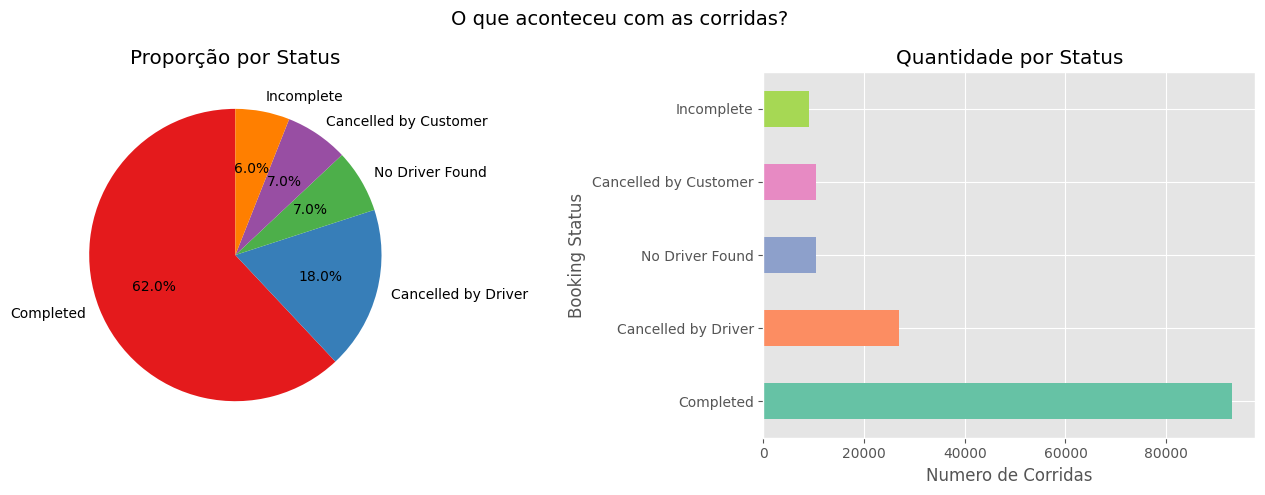

In [35]:
status = df["Booking Status"].value_counts()

fig, axes = plt.subplots(1,2, figsize=(13,5))
axes[0].pie(status.values, labels=status.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("Set1",len(status)))
axes[0].set_title("Proporção por Status")

status.plot(kind="barh", ax=axes[1], color=sns.color_palette("Set2", len(status)))
axes[1].set_title("Quantidade por Status")
axes[1].set_xlabel("Numero de Corridas")

plt.suptitle("O que aconteceu com as corridas?", fontsize=14)
plt.tight_layout()
plt.savefig("imagens/status_corridas.png", dpi=300, bbox_inches="tight")
plt.show()


MÉDIA DO VALOR DA CORRIDA POR TIPO DE VAÍCULO (apenas completadas):
Vehicle Type
Go Sedan         512.03
Premier Sedan    509.57
Bike             509.11
Go Mini          507.38
Auto             506.48
Uber XL          505.30
eBike            503.46
Name: Booking Value, dtype: float64


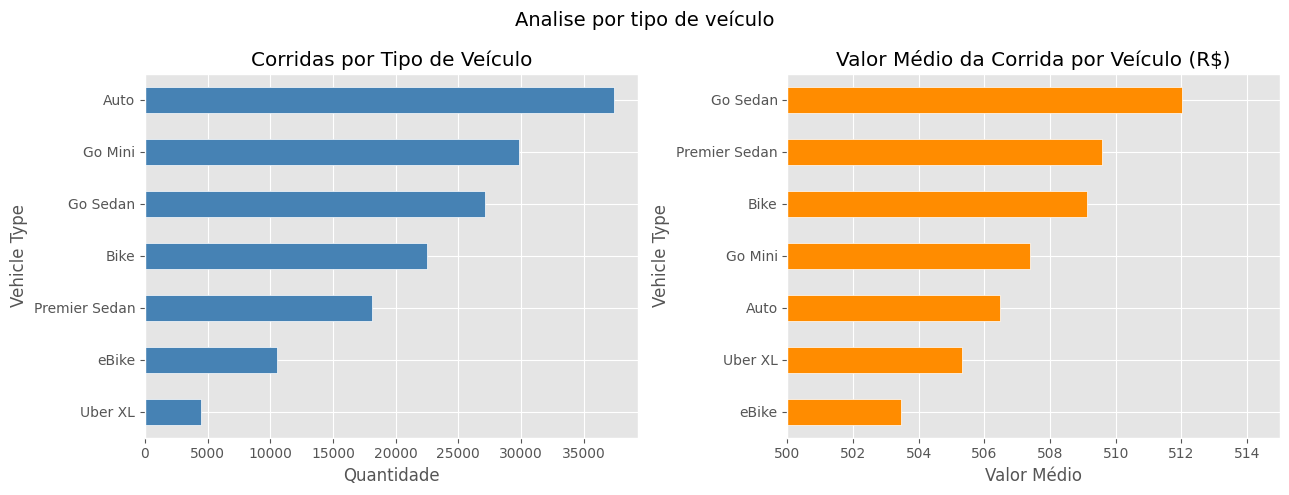

In [36]:
veic_qtd = df["Vehicle Type"].value_counts()
veic_valor = df_modelo.groupby("Vehicle Type")["Booking Value"].mean().sort_values(ascending=False)

print("\nMÉDIA DO VALOR DA CORRIDA POR TIPO DE VAÍCULO (apenas completadas):")
print(veic_valor.round(2))

fig, axes = plt.subplots(1,2, figsize=(13,5))
veic_qtd.sort_values().plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Corridas por Tipo de Veículo")
axes[0].set_xlabel("Quantidade")

veic_valor.sort_values().plot(kind="barh", ax=axes[1], color="darkorange", edgecolor="white")
axes[1].set_title("Valor Médio da Corrida por Veículo (R$)")
axes[1].set_xlabel("Valor Médio")

plt.xlim(500, 515)
plt.suptitle("Analise por tipo de veículo", fontsize=14)
plt.savefig("imagens/corridas_por_veiculo.png", dpi=300, bbox_inches="tight")
plt.savefig("imagens/valor_medio_por_veiculo.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

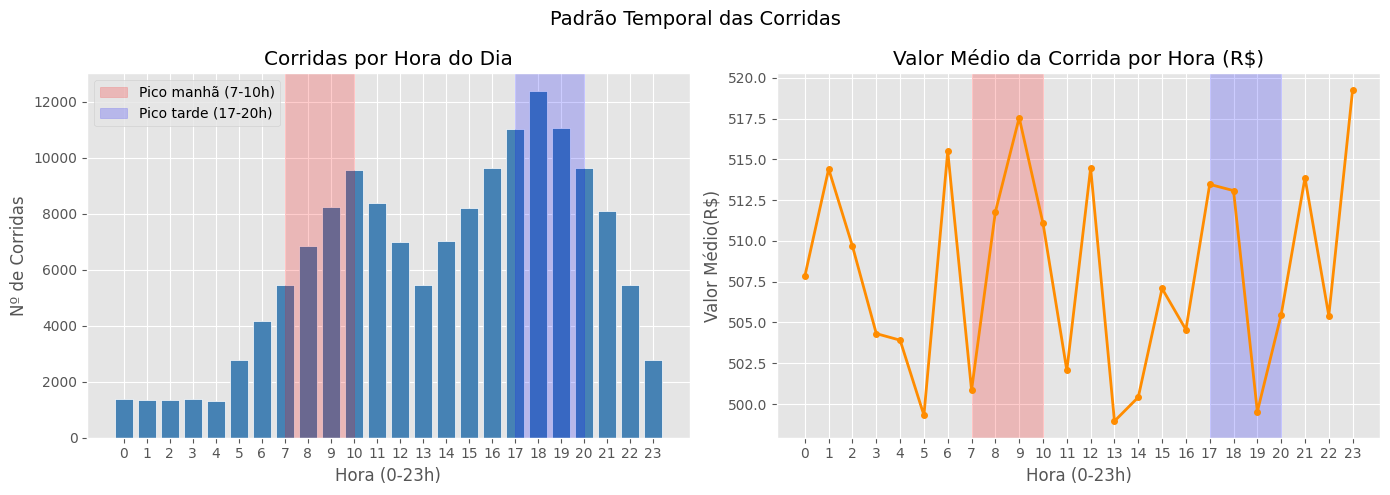

In [ ]:
corridas_hora = df.groupby(df["Time"].dt.hour).size()
valor_hora = df_modelo.assign(hora=df_modelo["Time"].dt.hour).groupby("hora")["Booking Value"].mean()

fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].bar(corridas_hora.index, corridas_hora.values, color="steelblue", edgecolor="white")
axes[0].axvspan(7,10, alpha=0.2, color="red", label="Pico manhã (7-10h)")
axes[0].axvspan(17,20, alpha=0.2, color="blue", label="Pico tarde (17-20h)")
axes[0].set_title("Corridas por Hora do Dia")
axes[0].set_xlabel("Hora (0-23h)")
axes[0].set_ylabel("Nº de Corridas")
axes[0].set_xticks(range(0,24))
axes[0].legend()

axes[1].plot(valor_hora.index, valor_hora.values, color="darkorange", linewidth=2, marker="o", markersize=4)
axes[1].axvspan(7,10, alpha=0.2, color="red")
axes[1].axvspan(17,20, alpha=0.2, color="blue")
axes[1].set_title("Valor Médio da Corrida por Hora (R$)")
axes[1].set_xlabel("Hora (0-23h)")
axes[1].set_ylabel("Valor Médio(R$)")
axes[1].set_xticks(range(0,24))

plt.suptitle("Padrão Temporal das Corridas", fontsize=14)
plt.savefig("imagens/corridas_por_hora.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

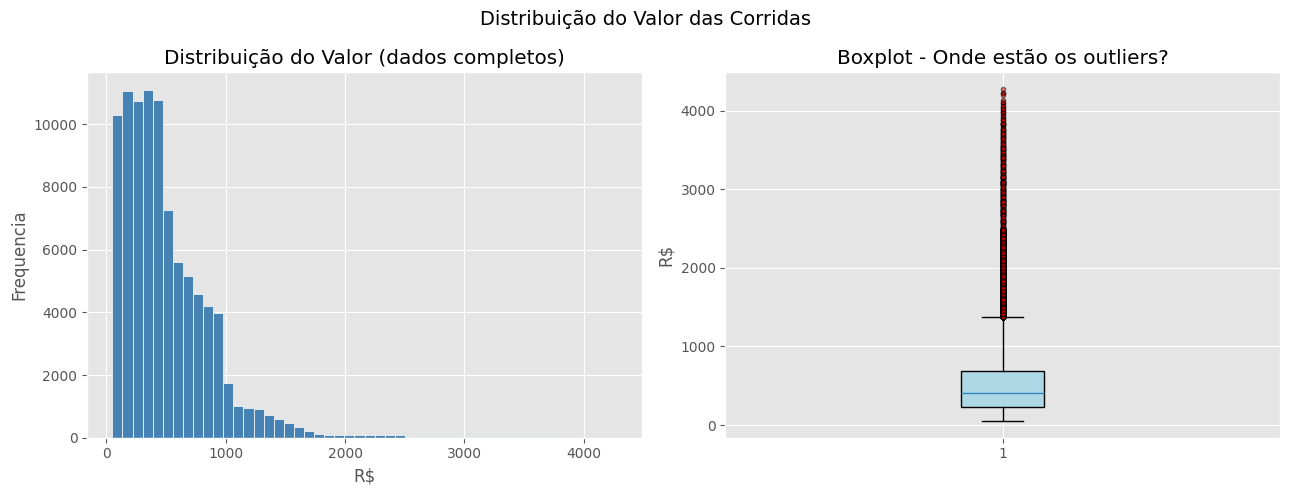

In [38]:
fig, axes = plt.subplots(1,2, figsize=(13,5))

axes[0].hist(df_modelo["Booking Value"].dropna(), bins=50, color="steelblue", edgecolor="white")

axes[0].set_title("Distribuição do Valor (dados completos)")
axes[0].set_xlabel("R$")
axes[0].set_ylabel("Frequencia")

axes[1].boxplot(df_modelo["Booking Value"].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor="lightblue"), flierprops=dict(marker="o", markersize=3, markerfacecolor="red", alpha=0.5))
axes[1].set_title("Boxplot - Onde estão os outliers?")
axes[1].set_ylabel("R$")

plt.suptitle("Distribuição do Valor das Corridas", fontsize=14)
plt.savefig("imagens/boxplot_valor_corridas.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

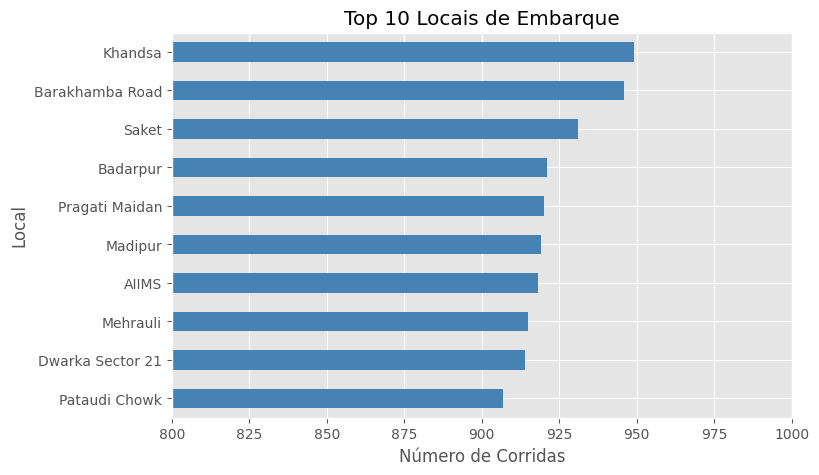

In [39]:
top_pickup = df["Pickup Location"].value_counts().head(10)

plt.figure(figsize=(8,5))
top_pickup.sort_values().plot(kind="barh", color="steelblue")
plt.xlim(800, 1000)
plt.savefig("imagens/top_locais_pickup.png", dpi=300, bbox_inches="tight")
plt.title("Top 10 Locais de Embarque")
plt.xlabel("Número de Corridas")
plt.ylabel("Local")
plt.show()